In [1]:
import pandas as pd
df = pd.read_excel("/Users/mainak/Documents/RetailSalesAnalyticsPyspark/Online Retail.xlsx")
df.to_csv("/Users/mainak/Documents/RetailSalesAnalyticsPyspark/online_retail.csv", index=False)
print(df.shape)

(541909, 8)


In [5]:
# Retail Sales Analytics using PySpark

## Objective
#Analyze large-scale retail transaction data using PySpark to identify:
#- total revenue and sales trends
#- top-selling products
#- high-value customers
#- country-level performance
#- frequent purchase patterns

## Tools
#- PySpark
#- Spark SQL
#- Python
#- Jupyter Notebook

In [6]:
import os
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("Retail Sales Analytics using PySpark") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()

print(spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/10 15:20:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


4.1.1


In [7]:
df = spark.read.csv("/Users/mainak/Documents/RetailSalesAnalyticsPyspark/online_retail.csv",header=True,inferSchema=True)
df.show(5)
df.printSchema()
print("Total Rows :",df.count())
print("Total Columns :",len(df.columns))

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows
root

In [8]:
df.columns

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [9]:
df.describe().show()

26/04/10 15:20:23 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 6:=======>                                                   (1 + 7) / 8]

+-------+-----------------+------------------+--------------------+------------------+-----------------+------------------+-----------+
|summary|        InvoiceNo|         StockCode|         Description|          Quantity|        UnitPrice|        CustomerID|    Country|
+-------+-----------------+------------------+--------------------+------------------+-----------------+------------------+-----------+
|  count|           541909|            541909|              540455|            541909|           541909|            406829|     541909|
|   mean| 559965.752026781|27623.240210938104|             20713.0|  9.55224954743324|4.611113626089732|15287.690570239585|       NULL|
| stddev|13428.41728079761|16799.737628427676|                NULL|218.08115785023438| 96.7598530611797|1713.6003033215961|       NULL|
|    min|           536365|             10002| 4 PURPLE FLOCK D...|            -80995|        -11062.06|           12346.0|  Australia|
|    max|          C581569|                 m|  

In [10]:
from pyspark.sql.functions import col, sum

df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [11]:
#REmove rows with missing critical fields
df_clean = df.na.drop(subset=["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"])

In [12]:
#Remove cancellation records
df_clean=df_clean.filter(~col("InvoiceNo").startswith("C"))

In [13]:
#Remove non-positive quantity and price
df_clean=df_clean.filter((col("Quantity")>0) & (col("UnitPrice")>0))

In [14]:
print("Rows after cleaning:", df_clean.count())

Rows after cleaning: 530104


In [15]:
#Revenue
from pyspark.sql.functions import round
df_clean=df_clean.withColumn("Revenue",round(col("Quantity")*col("UnitPrice"),2))

In [16]:
#Invoice Date Parsing
from pyspark.sql.functions import to_timestamp, to_date, year, month

df_clean = df_clean.withColumn("InvoiceTimestamp", to_timestamp(col("InvoiceDate"))) \
                   .withColumn("InvoiceDay", to_date(col("InvoiceTimestamp"))) \
                   .withColumn("InvoiceYear", year(col("InvoiceTimestamp"))) \
                   .withColumn("InvoiceMonth", month(col("InvoiceTimestamp")))


In [17]:
#Total revenue
from pyspark.sql.functions import sum as spark_sum
df_clean.select(spark_sum("Revenue").alias("TotalRevenue")).show()

+--------------------+
|        TotalRevenue|
+--------------------+
|1.0666684539998883E7|
+--------------------+



In [18]:
#Top 10 products by revenue
top_products=df_clean.groupBy("StockCode","Description").agg(spark_sum("Revenue").alias("TotalRevenue")).orderBy(col("TotalRevenue").desc())
top_products.show(10 , truncate=False)

[Stage 18:=======>                                                  (1 + 7) / 8]

+---------+----------------------------------+------------------+
|StockCode|Description                       |TotalRevenue      |
+---------+----------------------------------+------------------+
|DOT      |DOTCOM POSTAGE                    |206248.77         |
|22423    |REGENCY CAKESTAND 3 TIER          |174484.74         |
|23843    |PAPER CRAFT , LITTLE BIRDIE       |168469.6          |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|104340.29000000014|
|47566    |PARTY BUNTING                     |99504.32999999996 |
|85099B   |JUMBO BAG RED RETROSPOT           |94340.04999999981 |
|23166    |MEDIUM CERAMIC TOP STORAGE JAR    |81700.92000000004 |
|M        |Manual                            |78110.27          |
|POST     |POSTAGE                           |78101.88          |
|23084    |RABBIT NIGHT LIGHT                |66964.98999999987 |
+---------+----------------------------------+------------------+
only showing top 10 rows


In [20]:
#top 10 products by quantity sold
top_quantity_products = df_clean.groupBy("StockCode", "Description").agg(spark_sum("Quantity").alias("TotalQuantity")).orderBy(col("TotalQuantity").desc())

top_quantity_products.show(10, truncate=False)

[Stage 21:=======>                                                  (1 + 7) / 8]

+---------+----------------------------------+-------------+
|StockCode|Description                       |TotalQuantity|
+---------+----------------------------------+-------------+
|23843    |PAPER CRAFT , LITTLE BIRDIE       |80995        |
|23166    |MEDIUM CERAMIC TOP STORAGE JAR    |78033        |
|84077    |WORLD WAR 2 GLIDERS ASSTD DESIGNS |55047        |
|85099B   |JUMBO BAG RED RETROSPOT           |48474        |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|37599        |
|22197    |POPCORN HOLDER                    |36761        |
|84879    |ASSORTED COLOUR BIRD ORNAMENT     |36461        |
|21212    |PACK OF 72 RETROSPOT CAKE CASES   |36419        |
|23084    |RABBIT NIGHT LIGHT                |30788        |
|22492    |MINI PAINT SET VINTAGE            |26633        |
+---------+----------------------------------+-------------+
only showing top 10 rows


In [33]:
#the top 10 customers by revenue
top_customers = df_clean.filter(col("CustomerID").isNotNull()).groupBy("CustomerID").agg(spark_sum("Revenue").alias("TotalRevenue")).orderBy(col("TotalRevenue").desc())

top_customers.show(10)

+----------+------------------+
|CustomerID|      TotalRevenue|
+----------+------------------+
|   14646.0|280206.01999999984|
|   18102.0|259657.29999999996|
|   17450.0|194550.78999999998|
|   16446.0|          168472.5|
|   14911.0|143825.06000000003|
|   12415.0|124914.53000000003|
|   14156.0|117379.63000000003|
|   17511.0|          91062.38|
|   16029.0|          81024.84|
|   12346.0|           77183.6|
+----------+------------------+
only showing top 10 rows


In [21]:
#countries which generate the most revenue

country_revenue = df_clean.groupBy("Country").agg(spark_sum("Revenue").alias("TotalRevenue")).orderBy(col("TotalRevenue").desc())

country_revenue.show(10, truncate=False)

+--------------+------------------+
|Country       |TotalRevenue      |
+--------------+------------------+
|United Kingdom|9025222.079999503 |
|Netherlands   |285446.33999999997|
|EIRE          |283453.9599999997 |
|Germany       |228867.14000000007|
|France        |209715.11000000002|
|Australia     |138521.31         |
|Spain         |61577.110000000015|
|Switzerland   |57089.89999999996 |
|Belgium       |41196.34000000001 |
|Sweden        |38378.33000000001 |
+--------------+------------------+
only showing top 10 rows


In [22]:
#Monthly sales trend

monthly_sales = df_clean.groupBy("InvoiceYear", "InvoiceMonth").agg(spark_sum("Revenue").alias("MonthlyRevenue")).orderBy("InvoiceYear", "InvoiceMonth")

monthly_sales.show(20)

[Stage 27:====================================>                     (5 + 3) / 8]

+-----------+------------+------------------+
|InvoiceYear|InvoiceMonth|    MonthlyRevenue|
+-----------+------------+------------------+
|       2010|          12| 823746.1399999646|
|       2011|           1| 691364.5600000133|
|       2011|           2| 523631.8900000278|
|       2011|           3| 717639.3600000187|
|       2011|           4| 537808.6200000154|
|       2011|           5| 770536.0200000107|
|       2011|           6| 761739.9000000188|
|       2011|           7| 719221.1900000272|
|       2011|           8| 759138.3800000165|
|       2011|           9|1058590.1700000095|
|       2011|          10|1154979.2999999207|
|       2011|          11|1509496.3299998583|
|       2011|          12|  638792.680000013|
+-----------+------------+------------------+



In [25]:
#created a Spark SQL section,created a temp view to perform analysis using sql
df_clean.createOrReplaceTempView("retail_sales")

In [26]:
#Top countries by revenue
spark.sql("""
SELECT Country, ROUND(SUM(Revenue), 2) AS TotalRevenue
FROM retail_sales
GROUP BY Country
ORDER BY TotalRevenue DESC
LIMIT 10
""").show()


+--------------+------------+
|       Country|TotalRevenue|
+--------------+------------+
|United Kingdom|  9025222.08|
|   Netherlands|   285446.34|
|          EIRE|   283453.96|
|       Germany|   228867.14|
|        France|   209715.11|
|     Australia|   138521.31|
|         Spain|    61577.11|
|   Switzerland|     57089.9|
|       Belgium|    41196.34|
|        Sweden|    38378.33|
+--------------+------------+



In [27]:
#Top customers

spark.sql("""
SELECT CustomerID, ROUND(SUM(Revenue), 2) AS TotalRevenue
FROM retail_sales
WHERE CustomerID IS NOT NULL
GROUP BY CustomerID
ORDER BY TotalRevenue DESC
LIMIT 10
""").show()

[Stage 33:=======>                                                  (1 + 7) / 8]

+----------+------------+
|CustomerID|TotalRevenue|
+----------+------------+
|   14646.0|   280206.02|
|   18102.0|    259657.3|
|   17450.0|   194550.79|
|   16446.0|    168472.5|
|   14911.0|   143825.06|
|   12415.0|   124914.53|
|   14156.0|   117379.63|
|   17511.0|    91062.38|
|   16029.0|    81024.84|
|   12346.0|     77183.6|
+----------+------------+



In [28]:
#Top monthly sales
spark.sql("""
SELECT InvoiceYear, InvoiceMonth, ROUND(SUM(Revenue), 2) AS MonthlyRevenue
FROM retail_sales
GROUP BY InvoiceYear, InvoiceMonth
ORDER BY InvoiceYear, InvoiceMonth
""").show()



+-----------+------------+--------------+
|InvoiceYear|InvoiceMonth|MonthlyRevenue|
+-----------+------------+--------------+
|       2010|          12|     823746.14|
|       2011|           1|     691364.56|
|       2011|           2|     523631.89|
|       2011|           3|     717639.36|
|       2011|           4|     537808.62|
|       2011|           5|     770536.02|
|       2011|           6|      761739.9|
|       2011|           7|     719221.19|
|       2011|           8|     759138.38|
|       2011|           9|    1058590.17|
|       2011|          10|     1154979.3|
|       2011|          11|    1509496.33|
|       2011|          12|     638792.68|
+-----------+------------+--------------+



In [30]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


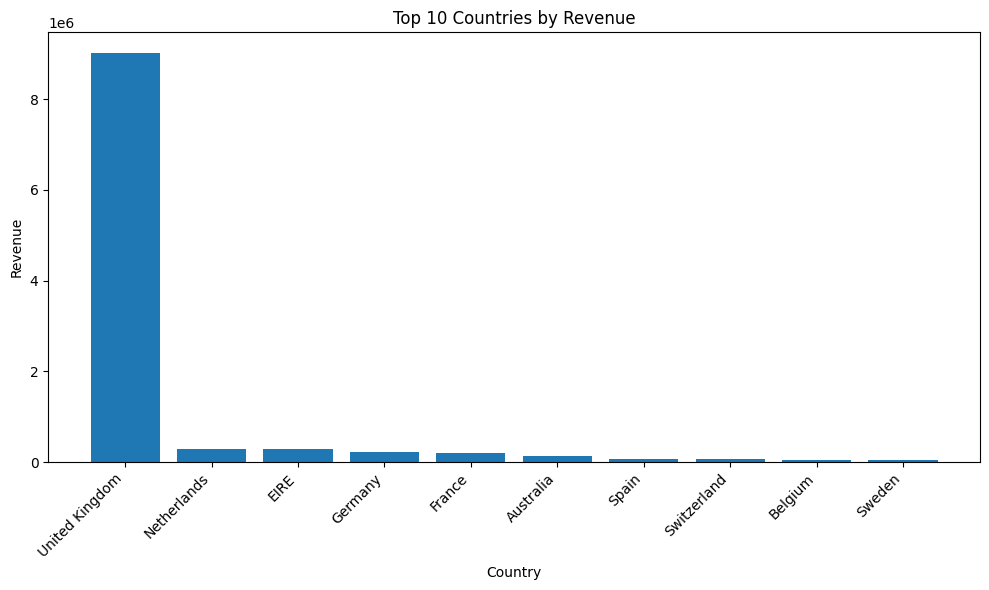

In [31]:
#Top 10 countries chart
country_pd = country_revenue.limit(10).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(country_pd["Country"], country_pd["TotalRevenue"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

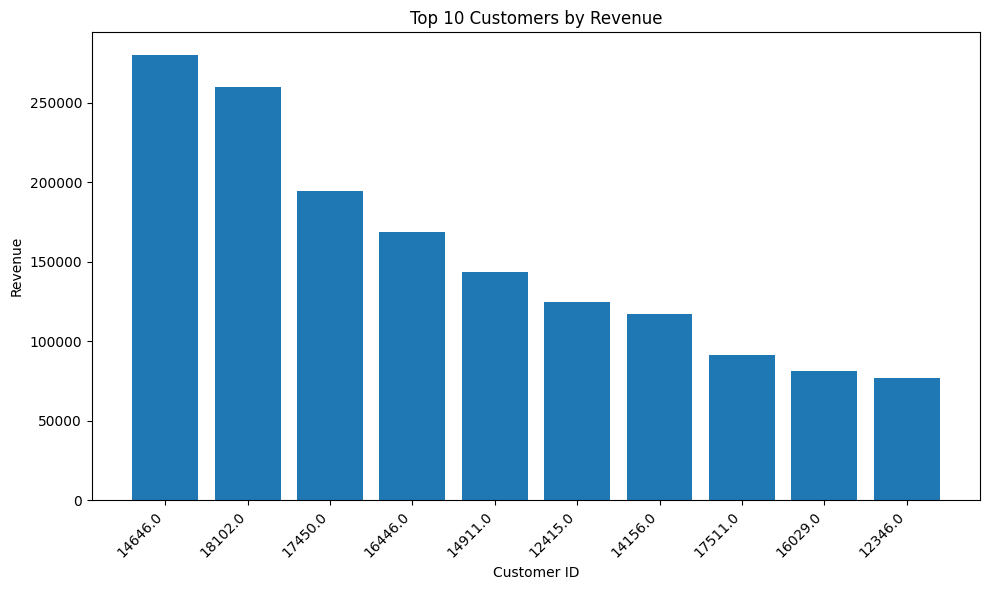

In [34]:
#Top customers chart
top_customers_pd = top_customers.limit(10).toPandas()

plt.figure(figsize=(10, 6))
plt.bar(top_customers_pd["CustomerID"].astype(str), top_customers_pd["TotalRevenue"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

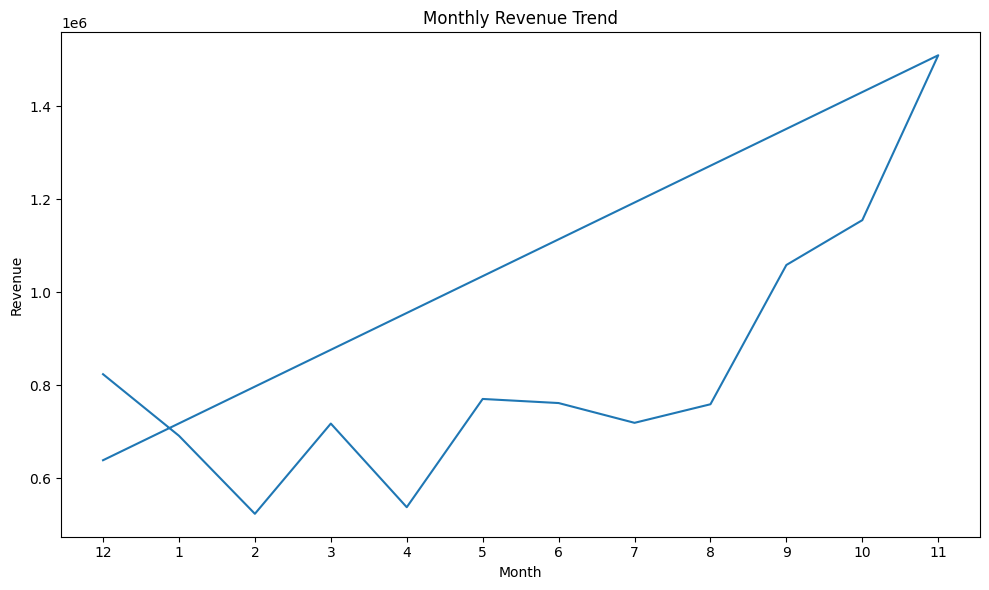

In [35]:
#Monthly sales chart
monthly_pd = monthly_sales.toPandas()

plt.figure(figsize=(10, 6))
plt.plot(monthly_pd["InvoiceMonth"].astype(str), monthly_pd["MonthlyRevenue"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()